In [76]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler



In [77]:
df_stars = pd.read_csv("stars.csv")
le = LabelEncoder()

# Assign unique integers from 0 to 6 to each star type (to go from string to integer)
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [78]:
# Analize the dataset
print (df_stars.shape)
print(df_stars.head())
print (df_stars.describe())

(240, 7)
   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   

   Star type Star color Spectral Class  
0          0        Red              M  
1          0        Red              M  
2          0        Red              M  
3          0        Red              M  
4          0        Red              M  
       Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
count       240.000000        240.000000    240.000000   
mean      10497.462500     107188.361635    237.157781   
std        9552.425037     179432.244940    517.155763   
min        1939.000000          0.000080    

In [79]:
# Are there any missing values?
print(df_stars.isnull().sum()) 
# Are there nan values?
print(df_stars.isna().sum())


Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64
Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64


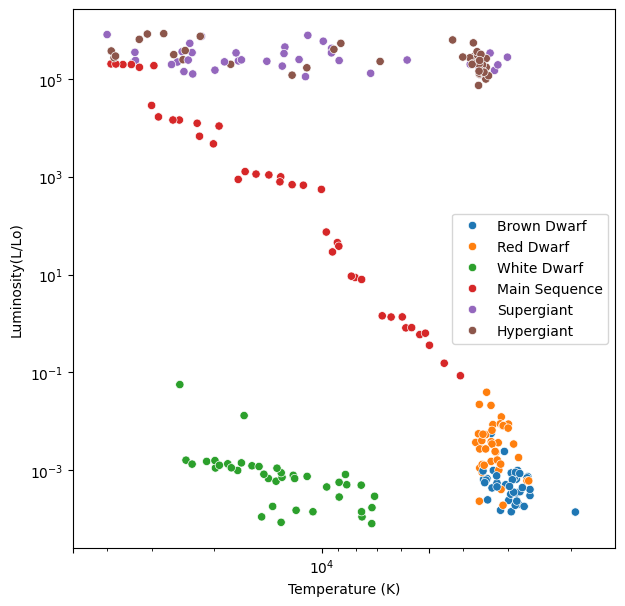

In [80]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [81]:
# Reduce the number of column to the one with real numbers. Remove the one with labels
X = df_stars.drop(columns=['Star type', 'Star color', 'Spectral Class'])
y = df_stars['Star type']

print (X.shape)
print(y.shape)
    

(240, 4)
(240,)


In [82]:
# Use PCA to reduce the dimensionality of the dataset to 4 dimensions
n_components = 4
pca = PCA(n_components=n_components)
pca.fit(X)
eigenvalues = pca.transform(X)
eigenvectors = pca.components_
print("eigenvalues: ", eigenvalues.shape)
print("eigenvectors: ", eigenvectors.shape)

eigenvalues:  (240, 4)
eigenvectors:  (4, 4)


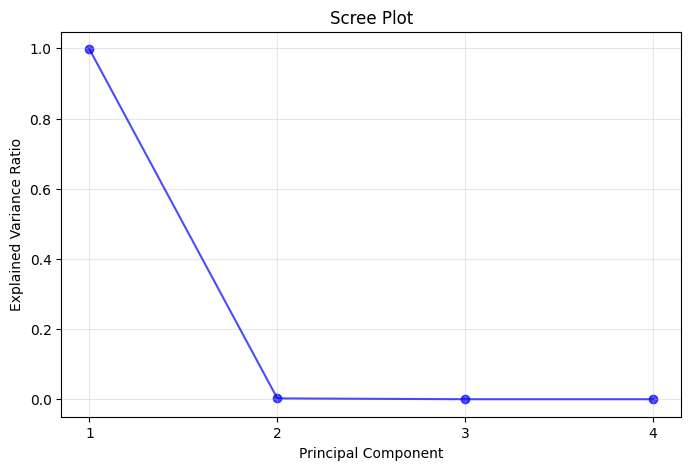

In [83]:
# Scree plot to see the variance of each component
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.scatter(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='blue')
plt.plot(range(1, len(explained_variance) + 1), explained_variance, color='blue', alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(alpha=0.3)
plt.show()

In [84]:
print("The first component explains the {:.2f}% of the variance.".format(explained_variance[0] * 100))
print("The second component explains the {:.2f}% of the variance.".format(explained_variance[1] * 100))
print("The third component explains the {:.2f}% of the variance.".format(explained_variance[2] * 100))
print("The fourth component explains the {:.2f}% of the variance.".format(explained_variance[3] * 100))

The first component explains the 99.76% of the variance.
The second component explains the 0.24% of the variance.
The third component explains the 0.00% of the variance.
The fourth component explains the 0.00% of the variance.


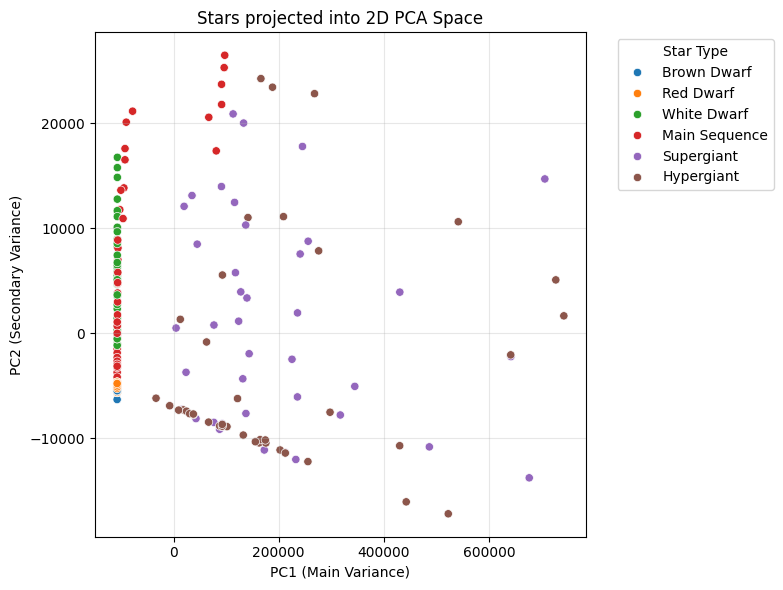

In [85]:
# Firs 2 component explain more than the 83% of the variance. Use them to make a 2d scatter plot

# scatter plot of the stars in the new 2D PCA space, colored by star type
plt.figure(figsize=(8, 6))
sns.scatterplot(x=eigenvalues[:,0], y=eigenvalues[:,1], hue=labels)
plt.xlabel('PC1 (Main Variance)')
plt.ylabel('PC2 (Secondary Variance)')
plt.title('Stars projected into 2D PCA Space')
plt.legend(title='Star Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [86]:
# The data are not well separated in the new 2D space
# try to use a manual rescale
def rescaler (x, values):
    return 2*((x-min(values))/(max(values)-min(values)))-1

data_scaled = 2 * ((X - X.min()) / (X.max() - X.min())) - 1

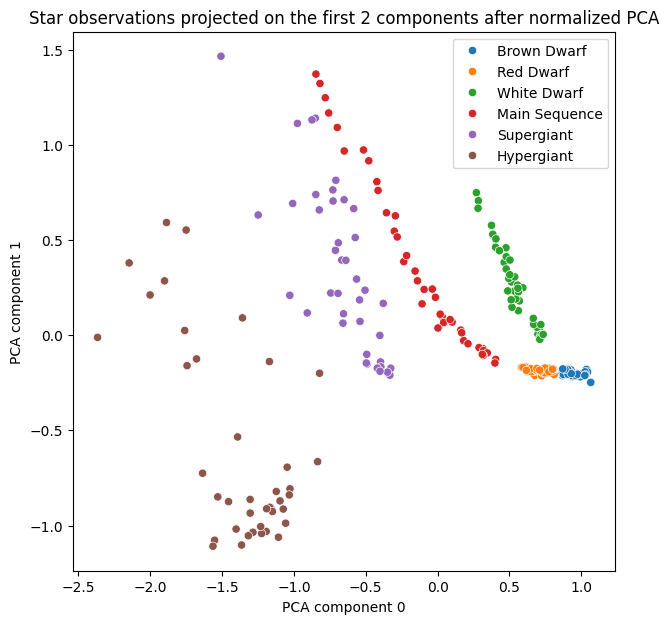

In [87]:
# PCA
pca_manual_rescaler = PCA()
manual_projected_stars = pca_manual_rescaler.fit_transform(data_scaled)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=manual_projected_stars[:,0], y=manual_projected_stars[:,1], hue=labels)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")

plt.title("Star observations projected on the first 2 components after normalized PCA")
plt.show()




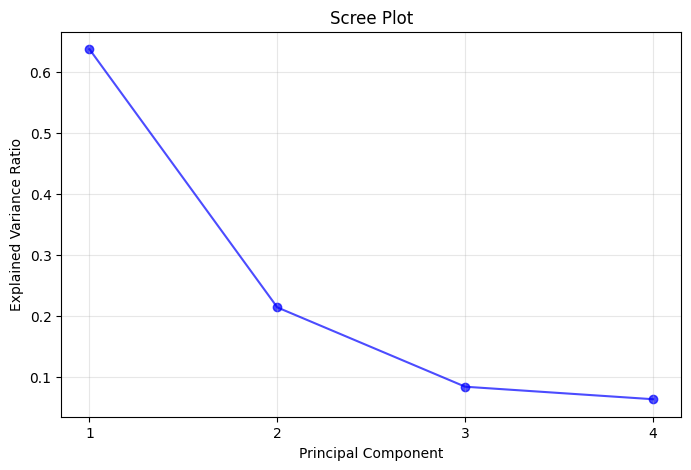

In [88]:
# Scree plot to see the variance of each component
explained_variance_manual = pca_manual_rescaler.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.scatter(range(1, len(explained_variance_manual) + 1), explained_variance_manual, alpha=0.7, color='blue')
plt.plot(range(1, len(explained_variance_manual) + 1), explained_variance_manual, color='blue', alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance_manual) + 1))
plt.grid(alpha=0.3)
plt.show()

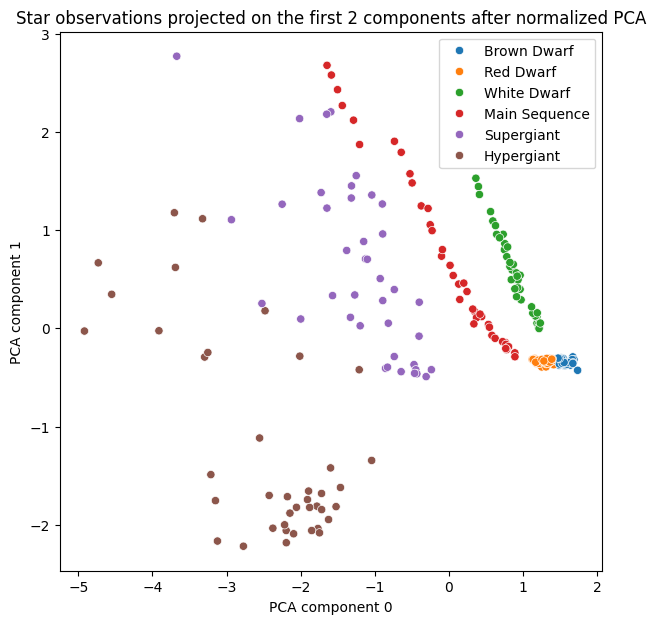

In [89]:
# Try to use a rescale using a standard scaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca_standard_scaler = PCA()
standard_projected_stars = pca_standard_scaler.fit_transform(X)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=standard_projected_stars[:,0], y=standard_projected_stars[:,1], hue=labels)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")

plt.title("Star observations projected on the first 2 components after normalized PCA")
plt.show()

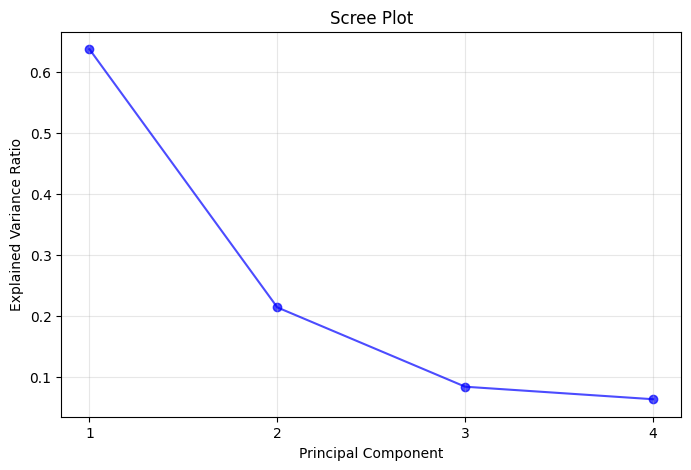

In [90]:
# Scree plot to see the variance of each component
explained_variance_standard = pca_standard_scaler.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.scatter(range(1, len(explained_variance_manual) + 1), explained_variance_manual, alpha=0.7, color='blue')
plt.plot(range(1, len(explained_variance_manual) + 1), explained_variance_manual, color='blue', alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance_manual) + 1))
plt.grid(alpha=0.3)
plt.show()

Text(0, 0.5, 'PC 4')

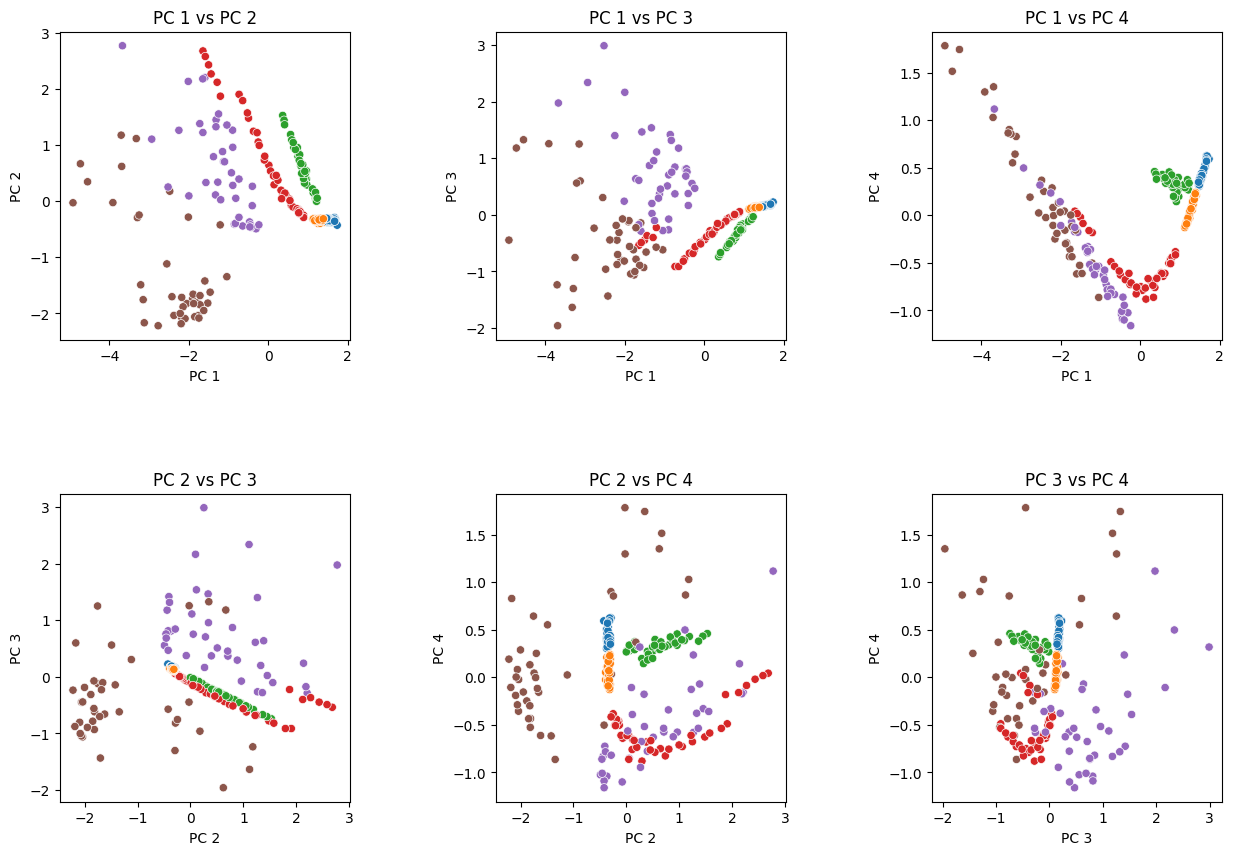

In [91]:
# Scatter plot of the 2D possible combination of eighenvalues
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.5)

sns.scatterplot(x=standard_projected_stars[:, 0], y=standard_projected_stars[:, 1], hue=labels, ax=axs[0, 0], legend=False)
axs[0, 0].set_title('PC 1 vs PC 2')
axs[0, 0].set_xlabel('PC 1')
axs[0, 0].set_ylabel('PC 2')

sns.scatterplot(x=standard_projected_stars[:, 0], y=standard_projected_stars[:, 2], hue=labels, ax=axs[0, 1], legend=False)
axs[0, 1].set_title('PC 1 vs PC 3')
axs[0, 1].set_xlabel('PC 1')
axs[0, 1].set_ylabel('PC 3')

sns.scatterplot(x=standard_projected_stars[:, 0], y=standard_projected_stars[:, 3], hue=labels, ax=axs[0, 2], legend=False)
axs[0, 2].set_title('PC 1 vs PC 4')
axs[0, 2].set_xlabel('PC 1')
axs[0, 2].set_ylabel('PC 4')

sns.scatterplot(x=standard_projected_stars[:, 1], y=standard_projected_stars[:, 2], hue=labels, ax=axs[1, 0], legend=False)
axs[1, 0].set_title('PC 2 vs PC 3')
axs[1, 0].set_xlabel('PC 2')
axs[1, 0].set_ylabel('PC 3')

sns.scatterplot(x=standard_projected_stars[:, 1], y=standard_projected_stars[:, 3], hue=labels, ax=axs[1, 1], legend=False)
axs[1, 1].set_title('PC 2 vs PC 4')
axs[1, 1].set_xlabel('PC 2')
axs[1, 1].set_ylabel('PC 4')

sns.scatterplot(x=standard_projected_stars[:, 2], y=standard_projected_stars[:, 3], hue=labels, ax=axs[1, 2], legend=False)
axs[1, 2].set_title('PC 3 vs PC 4')
axs[1, 2].set_xlabel('PC 3')
axs[1, 2].set_ylabel('PC 4')


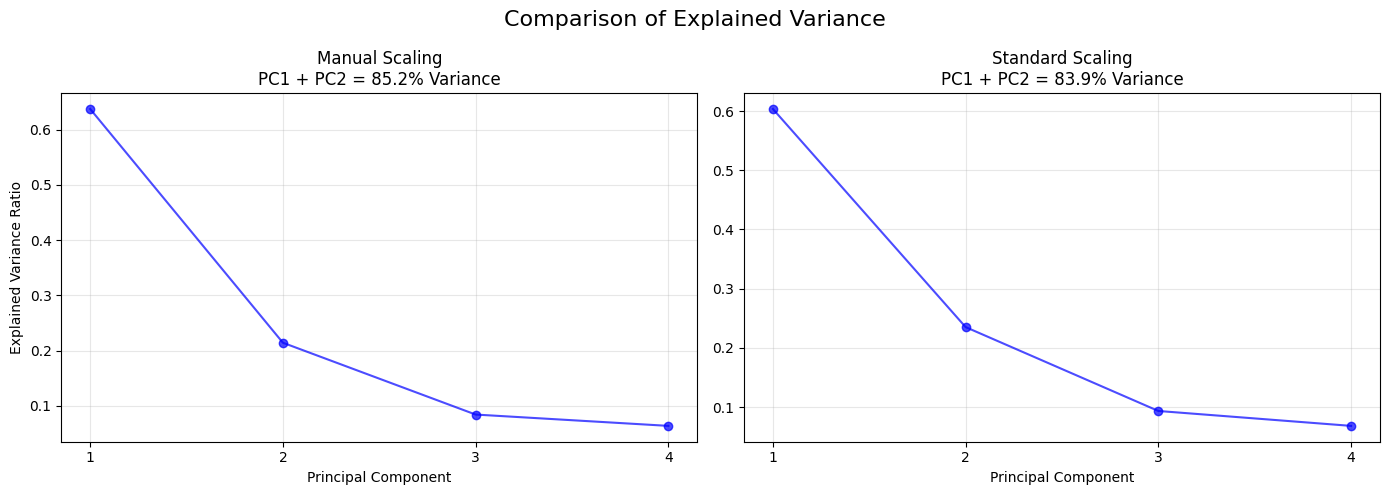

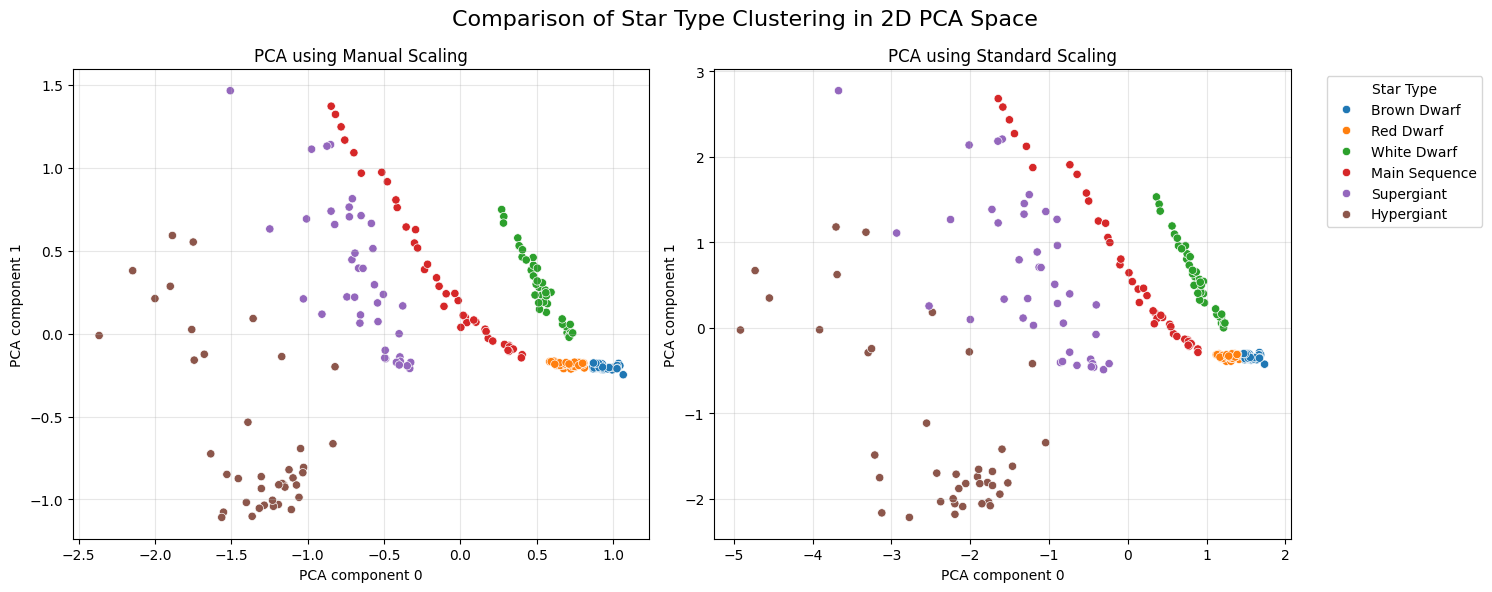

In [94]:
# Compare between the 2 scaler
ig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Manual Rescaler Scree
axs[0].plot(range(1, len(explained_variance_manual) + 1), explained_variance_manual, marker='o', color='blue', alpha=0.7)
axs[0].set_title(f'Manual Scaling\nPC1 + PC2 = {(explained_variance_manual[0]+explained_variance_manual[1])*100:.1f}% Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_ylabel('Explained Variance Ratio')
axs[0].set_xticks(range(1, len(explained_variance_manual) + 1))
axs[0].grid(alpha=0.3)

# Standard Scaler Scree
axs[1].plot(range(1, len(explained_variance_standard) + 1), explained_variance_standard, marker='o', color='blue', alpha=0.7)
axs[1].set_title(f'Standard Scaling\nPC1 + PC2 = {(explained_variance_standard[0]+explained_variance_standard[1])*100:.1f}% Variance')
axs[1].set_xlabel('Principal Component')
axs[1].set_xticks(range(1, len(explained_variance_standard) + 1))
axs[1].grid(alpha=0.3)

plt.suptitle("Comparison of Explained Variance", fontsize=16)
plt.tight_layout()
plt.show()

# Plot of the cluster
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Manual Rescaler Projection
sns.scatterplot(x=manual_projected_stars[:, 0], y=manual_projected_stars[:, 1], hue=labels, ax=axs[0], legend=False)
axs[0].set_title('PCA using Manual Scaling')
axs[0].set_xlabel('PCA component 0')
axs[0].set_ylabel('PCA component 1')
axs[0].grid(alpha=0.3)

# Standard Scaler Projection
sns.scatterplot(x=standard_projected_stars[:, 0], y=standard_projected_stars[:, 1], hue=labels, ax=axs[1])
axs[1].set_title('PCA using Standard Scaling')
axs[1].set_xlabel('PCA component 0')
axs[1].set_ylabel('PCA component 1')
axs[1].grid(alpha=0.3)
axs[1].legend(title='Star Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Comparison of Star Type Clustering in 2D PCA Space", fontsize=16)
plt.tight_layout()
plt.show()